# Define the seeds

In [1]:
import random
import os
import numpy as np

pi_digit_string = "1415926535897932384626433832795028841971"
seeds= [int(pi_digit_string[i:i+2]) for i in range(0, len(pi_digit_string), 2)]
print(len(seeds), seeds)

def set_seed(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

# Set the seed for reproducibility
set_seed(seeds[0])

20 [14, 15, 92, 65, 35, 89, 79, 32, 38, 46, 26, 43, 38, 32, 79, 50, 28, 84, 19, 71]


# Split the Dataset (Train/Test)

In [1]:
import pandas as pd
from sklearn.utils import shuffle

# Load preprocessed, normalized datasets, test set it the original one and train set is augmented.
df_test = pd.read_csv("../preprocessing/Augmented_rf/RF_raw/squat_dataset_test_original_normalized.csv")
df_train = pd.read_csv("../preprocessing/Augmented_rf/RF_raw/squat_dataset_train_augmented_and_original_normalized.csv")

#  Shuffle training data
df_train = shuffle(df_train, random_state=42).reset_index(drop=True)
df_test = shuffle(df_test, random_state=42).reset_index(drop=True)

feature_cols = [col for col in df_train.columns if col != "label"]

# Separate features and labels
X_train = df_train[feature_cols]
y_train = df_train["label"]

X_test = df_test[feature_cols]
y_test = df_test["label"]

print(f" Loaded features: {len(X_train)} training samples, {len(X_test)} test samples")
print(f" Using {len(feature_cols)} features")

 Loaded features: 880 training samples, 76 test samples
 Using 93 features


# Testing with original data import

In [2]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Load full combined dataset
df = pd.read_csv("../preprocessing/ready/squat_dataset_3d_raw.csv")

# Select feature columns, excluding any with "angle" in the name
feature_cols = [col for col in df.columns if col != "label" and "angle" not in col.lower()]

# Split into features and labels
X = df[feature_cols]
y = df["label"]

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=seeds[0]
)

# Confirm
print(f" Loaded and split: {len(X_train)} training samples, {len(X_test)} test samples")
print(f" Using {len(feature_cols)} features (excluding angles):\n{feature_cols}")


 Loaded and split: 201 training samples, 51 test samples
 Using 96 features (excluding angles):
['left_hip_x_mean', 'left_hip_x_std', 'left_hip_x_min', 'left_hip_x_max', 'left_hip_y_mean', 'left_hip_y_std', 'left_hip_y_min', 'left_hip_y_max', 'left_hip_z_mean', 'left_hip_z_std', 'left_hip_z_min', 'left_hip_z_max', 'right_hip_x_mean', 'right_hip_x_std', 'right_hip_x_min', 'right_hip_x_max', 'right_hip_y_mean', 'right_hip_y_std', 'right_hip_y_min', 'right_hip_y_max', 'right_hip_z_mean', 'right_hip_z_std', 'right_hip_z_min', 'right_hip_z_max', 'left_knee_x_mean', 'left_knee_x_std', 'left_knee_x_min', 'left_knee_x_max', 'left_knee_y_mean', 'left_knee_y_std', 'left_knee_y_min', 'left_knee_y_max', 'left_knee_z_mean', 'left_knee_z_std', 'left_knee_z_min', 'left_knee_z_max', 'right_knee_x_mean', 'right_knee_x_std', 'right_knee_x_min', 'right_knee_x_max', 'right_knee_y_mean', 'right_knee_y_std', 'right_knee_y_min', 'right_knee_y_max', 'right_knee_z_mean', 'right_knee_z_std', 'right_knee_z_min',

# Cross-Validation with Best Parameters Logging

In [3]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import math

# Define your hyperparameter grid
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [
        int(math.sqrt(X_train.shape[1])),
        int(2 * math.sqrt(X_train.shape[1])),
        int(3 * math.sqrt(X_train.shape[1])),
        None
    ],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
}

# 5-fold Stratified Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seeds[0])

# Initialize model
rf = RandomForestClassifier(random_state=seeds[0])

# Run Grid Search CV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

# Print best results
print(f"\n✅ Best Parameters: {grid_search.best_params_}")
print(f"✅ Best Cross-Validated Accuracy: {grid_search.best_score_:.4f}")

# View top results
results_df = pd.DataFrame(grid_search.cv_results_).sort_values(by="mean_test_score", ascending=False)
print(results_df[["mean_test_score", "std_test_score", "params"]].head())

Fitting 5 folds for each of 324 candidates, totalling 1620 fits

✅ Best Parameters: {'max_depth': 9, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
✅ Best Cross-Validated Accuracy: 0.9900
     mean_test_score  std_test_score  \
168             0.99        0.012247   
87              0.99        0.012247   
255             0.99        0.012247   
6               0.99        0.012247   
249             0.99        0.012247   

                                                params  
168  {'max_depth': 29, 'max_features': 'sqrt', 'min...  
87   {'max_depth': 19, 'max_features': 'sqrt', 'min...  
255  {'max_depth': None, 'max_features': 'sqrt', 'm...  
6    {'max_depth': 9, 'max_features': 'sqrt', 'min_...  
249  {'max_depth': None, 'max_features': 'sqrt', 'm...  


# Train the Final Model

In [5]:
from sklearn.ensemble import RandomForestClassifier
import joblib

# Get best params from grid search
best_params = grid_search.best_params_

# Create and train model with best parameters
best_rf = RandomForestClassifier(**best_params, random_state=seeds[0])
best_rf.fit(X_train, y_train)

# Save the trained model
joblib.dump(best_rf, "trained_models/rf_model_raw_features.pkl")

print("✅ Random Forest model trained and saved!")

✅ Random Forest model trained and saved!


#  Evaluate the Model

In [39]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from collections import defaultdict

best_params = grid_search.best_params_

# Store metrics
results = defaultdict(list)

# Evaluate on multiple test splits using different seeds
for seed in seeds:
    print(f"\n Evaluating with test split from seed {seed}")
    set_seed(seed)

    # Resplit data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed
    )

    best_rf = RandomForestClassifier(**best_params, random_state=seed)
    best_rf.fit(X_train, y_train)

    # Predict labels and probabilities
    y_pred = best_rf.predict(X_test)
    y_proba = best_rf.predict_proba(X_test)[:, 1]

    # Compute metrics
    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    # Store standard metrics
    results["accuracy"].append(report["accuracy"])
    results["precision"].append(report["1"]["precision"])
    results["recall"].append(report["1"]["recall"])
    results["f1"].append(report["1"]["f1-score"])
    results["roc_auc"].append(roc_auc)

    # Store confusion matrix components
    results["tp"].append(cm[1, 1])
    results["fn"].append(cm[1, 0])
    results["fp"].append(cm[0, 1])
    results["tn"].append(cm[0, 0])

#  Summary
print("\n Final evaluation over multiple test splits:")
for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    values = results[metric]
    print(f"{metric.capitalize():<10}: {np.mean(values):.4f} ± {np.std(values):.4f}")

#  Average Confusion Matrix
avg_cm = np.array([
    [np.mean(results["tn"]), np.mean(results["fp"])],
    [np.mean(results["fn"]), np.mean(results["tp"])]
]).round().astype(int)

print("\n🧩 Mean Confusion Matrix (rounded):")
print(avg_cm)


 Evaluating with test split from seed 14

 Evaluating with test split from seed 15

 Evaluating with test split from seed 92

 Evaluating with test split from seed 65

 Evaluating with test split from seed 35

 Evaluating with test split from seed 89

 Evaluating with test split from seed 79

 Evaluating with test split from seed 32

 Evaluating with test split from seed 38

 Evaluating with test split from seed 46

 Evaluating with test split from seed 26

 Evaluating with test split from seed 43

 Evaluating with test split from seed 38

 Evaluating with test split from seed 32

 Evaluating with test split from seed 79

 Evaluating with test split from seed 50

 Evaluating with test split from seed 28

 Evaluating with test split from seed 84

 Evaluating with test split from seed 19

 Evaluating with test split from seed 71

 Final evaluation over multiple test splits:
Accuracy  : 0.9676 ± 0.0279
Precision : 0.9547 ± 0.0391
Recall    : 0.9820 ± 0.0296
F1        : 0.9677 ± 0.0278
Ro

# t-distributed stochastic neighbor embedding

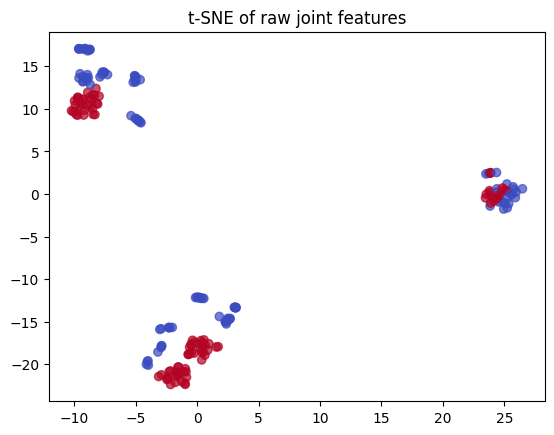

In [38]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Resplit data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=seeds[0]
)

X_embedded = TSNE(n_components=2, random_state=seeds[0]).fit_transform(X_train)
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y_train, cmap='coolwarm', alpha=0.7)
plt.title("t-SNE of raw joint features")
plt.show()
